# Variational AutoEncoder

**Author:** [fchollet](https://twitter.com/fchollet)<br>
**Date created:** 2020/05/03<br>
**Last modified:** 2024/04/24<br>
**Description:** Convolutional Variational AutoEncoder (VAE) trained on MNIST digits.

### **Modify by Dr. Chih Lai to demostrate "walk" an image of digit 6 toward another image of digit 0**

## Setup

In [ ]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import numpy as np
import tensorflow as tf
import keras
from keras import ops
from keras import layers

## Create a sampling layer

In [ ]:

class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.seed_generator = keras.random.SeedGenerator(1337)

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = ops.shape(z_mean)[0]
        dim = ops.shape(z_mean)[1]
        epsilon = keras.random.normal(shape=(batch, dim), seed=self.seed_generator)
        return z_mean + ops.exp(0.5 * z_log_var) * epsilon


## Build the encoder

## **By Dr. Chih Lai, modify variable "latent_dim" from 2 to 30 for better "walking" example**

In [ ]:
latent_dim = 30

encoder_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 14, 14,    │        320 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 3136)      │          0 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │     50,192 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 30)        │        510 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 30)        │        510 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_1          │ (None, 30)        │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 70,028 (273.55 KB)

 Trainable params: 70,028 (273.55 KB)

 Non-trainable params: 0 (0.00 B)

## Build the decoder

In [ ]:
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3136)           │        97,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,897 (597.25 KB)

 Trainable params: 152,897 (597.25 KB)

 Non-trainable params: 0 (0.00 B)

## Define the VAE as a `Model` with a custom `train_step`


# **Annotation by Dr. Chih Lai** **bold text**
**"keras.Model"** class provides the entire training infrastructure: batching, shuffling, callbacks, metrics, etc.

Normally, Model.fit() uses a default implementation of train_step()
# The **train_step()** method in the example code overrides Keras’s default behavior

In [ ]:

class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")
        print("VAE initialized")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = ops.mean(
                ops.sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2),
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var))
            kl_loss = ops.mean(ops.sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        print("vae.train_step()")
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }


In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
mnist_digits = np.concatenate([x_train, x_test], axis=0)
mnist_digits = np.expand_dims(mnist_digits, -1).astype("float32") / 255

## Train the VAE

In [ ]:
vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())
vae.fit(mnist_digits, epochs=30, batch_size=128)

VAE initialized
Epoch 1/30
vae.train_step()
vae.train_step()
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - kl_loss: 3.3685 - loss: 256.7773 - reconstruction_loss: 253.4088
Epoch 2/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 3.0286 - loss: 195.6716 - reconstruction_loss: 192.6431
Epoch 3/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 3.2490 - loss: 191.7043 - reconstruction_loss: 188.4553
Epoch 4/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - kl_loss: 3.1498 - loss: 187.1965 - reconstruction_loss: 184.0468
Epoch 5/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 3.0618 - loss: 184.9831 - reconstruction_loss: 181.9213
Epoch 6/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 3.0385 - loss: 182.9648 - reconstruction_loss: 179.9263
Epoch 7/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - kl_loss: 3.1208 - loss: 181.5959 - reconstruction_loss: 178.4751
Epoch 8/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - kl_loss: 3.2087 - loss: 179.6755 - reconstruction_loss: 176.4

# **The following sections were created by Dr. Chih Lai to demostrate walking in the latent space**

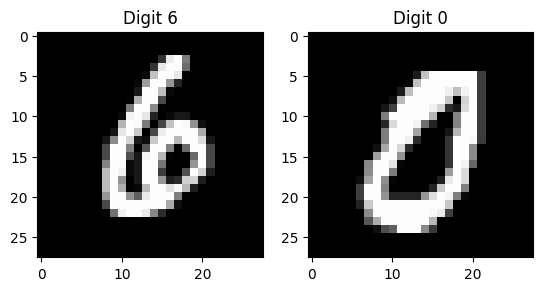

In [ ]:
x6 = x_train[y_train == 6][10]
x0 = x_train[y_train == 0][10]

plt.subplot(1, 2, 1)
plt.imshow(x6.squeeze(), cmap="gray")
plt.title("Digit 6")

plt.subplot(1, 2, 2)
plt.imshow(x0.squeeze(), cmap="gray")
plt.title("Digit 0")

plt.show()

# **Get Zs from digit 6 and 0 to prepare "walk"**

In [ ]:
z_mean_6, z_log_var_6, z_6 = encoder.predict(np.expand_dims(x6, 0))
z_mean_0, z_log_var_0, z_0 = encoder.predict(np.expand_dims(x0, 0))

epsilon_6 = np.random.normal(size=z_mean_6.shape)
z_real_6 = z_mean_6 + np.exp(0.5 * z_log_var_6) * epsilon_6

epsilon_0 = np.random.normal(size=z_mean_0.shape)
z_real_0 = z_mean_0 + np.exp(0.5 * z_log_var_0) * epsilon_0


# --- Remove the leading batch dimension so each is (latent_dim,) ---
z_real_6 = z_real_6.squeeze()   # or z_real_6[0]
z_real_0 = z_real_0.squeeze()   # or z_real_0[0]

print(z_mean_6)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
[[-1.4000733e-02  1.9057887e-03 -1.0870891e-02 -9.4964597e-03
  -2.9785750e-03 -6.2007001e-03  1.1813520e-03 -1.2207166e-03
  -9.8700505e-03  4.2644595e-03 -1.7918821e-02  6.9207596e-03
   1.9494506e-03  2.7892827e-03  3.1174303e-03  1.3048524e-02
   7.8176809e-03  2.8280991e-03 -9.3492344e-03 -3.8993177e-03
  -1.4806235e+00  1.3781991e-04 -3.8406486e-03 -1.2301155e-03
   8.2823653e-03 -6.6341362e-03  6.4416195e-04 -4.9390723e-03
  -2.0046881e-03  3.0415822e-03]]


# **WALK**

In [ ]:
import numpy as np

n_steps = 5
alphas = np.linspace(0, 1, n_steps)  # 0.0 ... 1.0
# Interpolated latent vectors
z_walk = np.array([(1 - a) * z_real_6 + a * z_real_0 for a in alphas])  # shape (n_steps, latent_dim)


## **Decode each interpolated vector**

In [ ]:
decoded_walk = decoder.predict(z_walk)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step


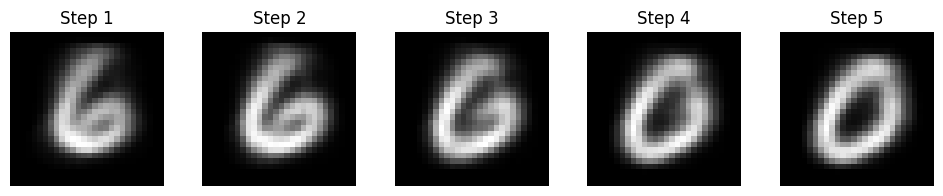

In [ ]:
plt.figure(figsize=(12, 2))
for i, img in enumerate(decoded_walk):
    plt.subplot(1, n_steps, i + 1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.axis('off')
    plt.title(f"Step {i+1}")
#plt.suptitle("Latent walk: 6 → 0", fontsize=14)
plt.show()